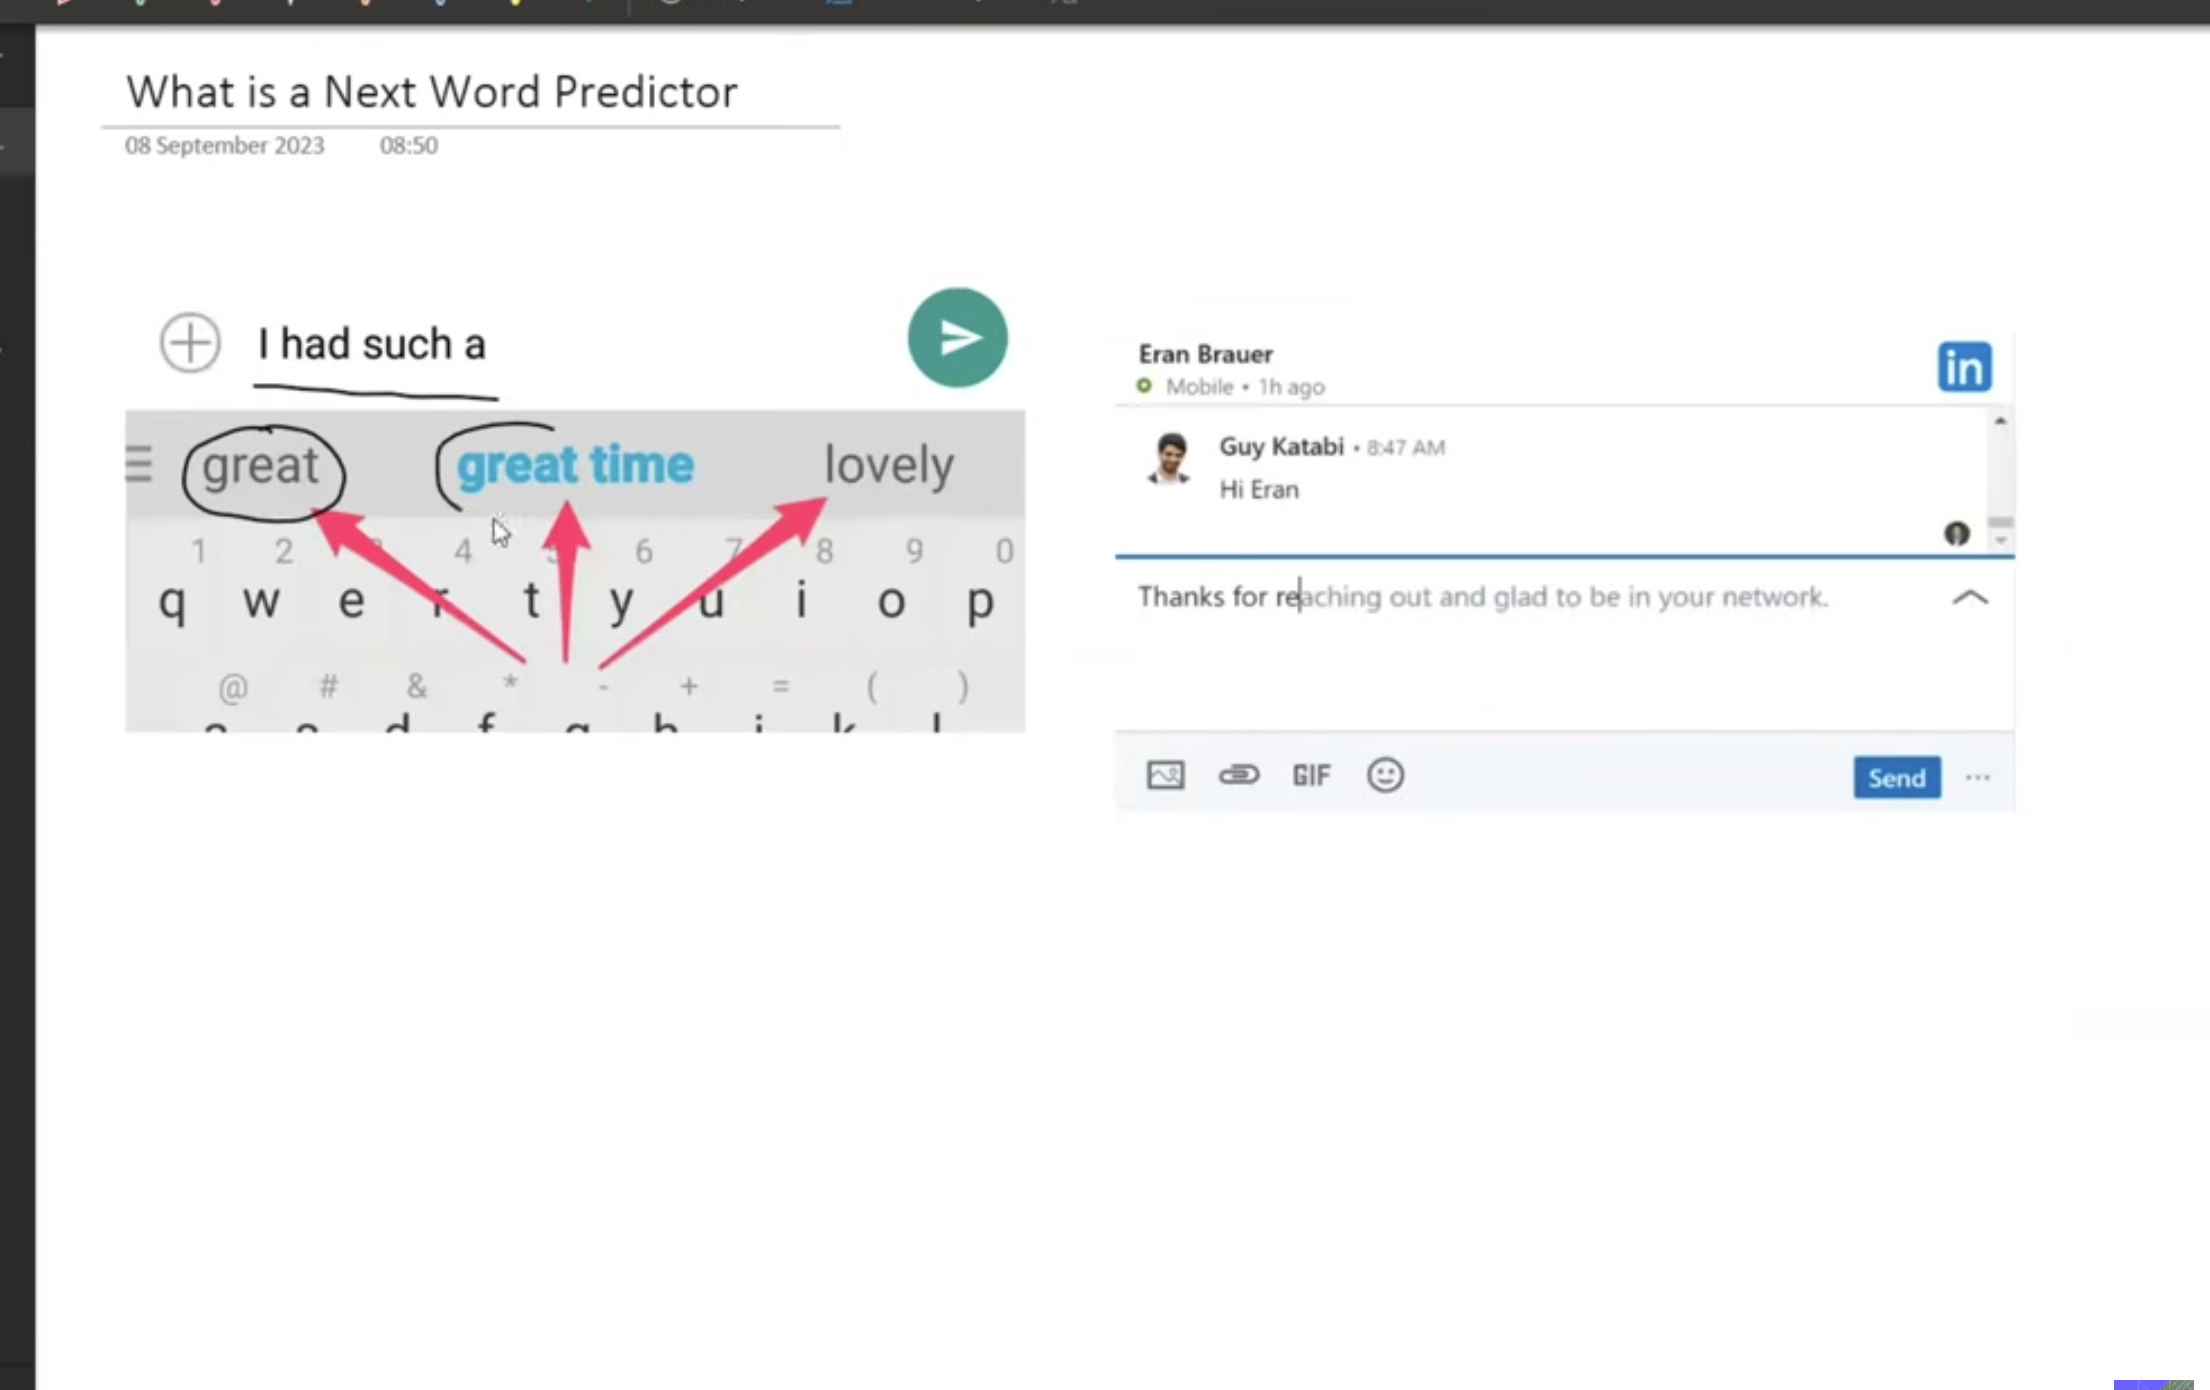

# Topic 1: Introduction to Next Word Predictors & Problem Formulation

## 1. Introduction

A **next word predictor** is a system that suggests the most probable next word given a sequence of preceding words. You've been using this technology daily without realizing it:

- **Smartphone keyboards** (SwiftKey, Gboard) – suggest next words as you type
- **Gmail Smart Compose** – completes sentences for you
- **Code completion tools** (like GitHub Copilot) – suggest next lines of code

**Why it matters:** These systems save time, reduce typing effort, and have become essential in modern digital communication. The first model used by SwiftKey for this purpose was actually an **LSTM** (Long Short-Term Memory) network.

**Real-life use:** Whenever you type "I am going to" and your phone suggests "the" or "school" – that's a next word predictor in action.

---

## 2. Detailed Explanation

### The Core Problem: Converting Text Generation to Supervised Learning

Text generation (predicting the next word) is naturally a **sequence prediction problem**. But machine learning models work best with **supervised learning** – where we have clear input-output pairs.

**The Strategy:**
We need to transform raw text into a dataset with explicit input-output mappings.

#### Step-by-Step Example

Consider two sentences:
- Sentence 1: "Hi, my name is Nitish."
- Sentence 2: "I live in Gurgaon."

**Goal:** Create input-output pairs where:
- **Input** = sequence of words seen so far
- **Output** = the next word that should follow

**How we create pairs (word by word):**

| For Sentence 1 | |
|---|---|
| Input | Output (next word) |
| "Hi" | "my" |
| "Hi my" | "name" |
| "Hi my name" | "is" |
| "Hi my name is" | "Nitish" |

| For Sentence 2 | |
|---|---|
| Input | Output (next word) |
| "I" | "live" |
| "I live" | "in" |
| "I live in" | "Gurgaon" |

**Visual representation:**
```
Sentence: "Hi my name is Nitish"
           ↓
Pairs:     Hi          → my
           Hi my       → name
           Hi my name  → is
           Hi my name is → Nitish
```

### The Problem: Machines Don't Understand Words

Machine learning models don't understand English (or any language) – they only understand **numbers**. So we must convert every word to a numeric representation.

**Example mapping:**
```
"Hi"      → 1
"my"      → 2
"name"    → 3
"is"      → 4
"Nitish"  → 5
```

**Transformed dataset:**
```
Input (numbers)          → Output (number)
[1]                      → 2
[1, 2]                   → 3
[1, 2, 3]                → 4
[1, 2, 3, 4]             → 5
```

Now the LSTM can process this numerical data!

### The Complete Workflow

```
Raw Text → Word Indexing → Create Input-Output Pairs → Train LSTM → Predict Next Word
```

1. **Assign numbers** to every unique word in your dataset (tokenization)
2. **Create sequences** of varying lengths as inputs, with the next word as output
3. **Train the LSTM** on these input-output pairs
4. **Given new text**, convert to numbers, feed to LSTM, get predicted next word

---

## 3. Key Points

- ✅ Next word predictor = **text generation** task framed as **supervised learning**
- ✅ Dataset is built **sentence by sentence**, creating pairs of (previous words → next word)
- ✅ Input sequences can be of **varying lengths** (1 word, 2 words, 3 words, etc.)
- ✅ LSTMs are well-suited because they can handle **sequential data** and remember context
- ✅ Models process **numbers**, not words → need **tokenization**
- ✅ Every unique word gets a **unique integer index**
- ✅ For better performance, you need **larger datasets** (the demo uses a small FAQ dataset)

---

## 4. Syntax/Structure – Tokenizer Setup (Keras)

```python
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer

# Step 1: Create tokenizer object
tokenizer = Tokenizer()

# Step 2: Fit tokenizer on your text data
# Note: text_data must be a list of strings
tokenizer.fit_on_texts(text_data)

# Step 3: Access the word-to-index mapping
word_index = tokenizer.word_index
# This gives a dictionary like: {'hi': 1, 'my': 2, 'name': 3, ...}
```

### Line-by-line explanation:

| Code | Purpose |
|------|---------|
| `from tensorflow.keras.preprocessing.text import Tokenizer` | Import the Tokenizer class from Keras |
| `tokenizer = Tokenizer()` | Create an instance of the Tokenizer |
| `tokenizer.fit_on_texts([text])` | Learn the vocabulary; assign a unique integer to each word. Input must be a list. |
| `tokenizer.word_index` | Dictionary containing word→number mappings |

### Converting sentences to sequences:

```python
# Convert a sentence to its numeric representation
sentence = "Hi my name is Nitish"
sequence = tokenizer.texts_to_sequences([sentence])
# Output: [[1, 2, 3, 4, 5]]
```

| Method | Purpose |
|--------|---------|
| `texts_to_sequences([sentence])` | Converts text to list of numbers using the trained vocabulary |

---

## 5. Code Example

### Basic Tokenization Example

```python
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer

# Sample corpus (must be a list of strings)
corpus = [
    "Hi my name is Nitish",
    "I live in Gurgaon"
]

# Step 1: Create and fit tokenizer
tokenizer = Tokenizer()
tokenizer.fit_on_texts(corpus)   # Learns vocabulary from all texts

# Step 2: See the word-to-number mapping
word_index = tokenizer.word_index
print("Word to index mapping:")
print(word_index)
# Output: {'hi': 1, 'my': 2, 'name': 3, 'is': 4, 'nitish': 5, 'i': 6, 'live': 7, 'in': 8, 'gurgaon': 9}

# Step 3: Convert a sentence to numbers
sentence = "Hi my name is Nitish"
sequence = tokenizer.texts_to_sequences([sentence])
print("\nNumeric sequence:")
print(sequence)
# Output: [[1, 2, 3, 4, 5]]

# Step 4: Convert multiple sentences
all_sequences = tokenizer.texts_to_sequences(corpus)
print("\nAll sequences:")
print(all_sequences)
# Output: [[1, 2, 3, 4, 5], [6, 7, 8, 9]]
```

### Sentence Splitting

```python
# For a multi-line text, split by newlines to get individual sentences
text_data = """Hi my name is Nitish
I live in Gurgaon
Python is great"""

sentences = text_data.split('\n')   # Splits on newline characters
print(sentences)
# Output: ['Hi my name is Nitish', 'I live in Gurgaon', 'Python is great']

# Each element becomes a separate sentence for creating input-output pairs
```

---

## 6. Output Explanation

**After `fit_on_texts()`:**
```python
tokenizer.word_index
```
**Output:**
```python
{'hi': 1, 'my': 2, 'name': 3, 'is': 4, 'nitish': 5, 'i': 6, 'live': 7, 'in': 8, 'gurgaon': 9}
```
- Every unique word gets a unique integer
- Indexing starts from 1 (0 is usually reserved for padding)
- Case sensitivity: "Hi" and "hi" might be treated differently unless preprocessed

**After `texts_to_sequences()`:**
```python
tokenizer.texts_to_sequences(["Hi my name is Nitish"])
```
**Output:**
```python
[[1, 2, 3, 4, 5]]
```
- Each word is replaced by its corresponding integer
- The result is a list of lists (each inner list = one sentence)

---

## 7. Common Mistakes

| ❌ Mistake | ✅ Solution |
|-----------|------------|
| Forgetting to pass text as a **list** to `fit_on_texts()` | Always use: `tokenizer.fit_on_texts([text])` or `tokenizer.fit_on_texts(list_of_texts)` |
| Assuming tokenizer preserves original capitalization | Tokenizer is **case-sensitive** by default. Preprocess with `.lower()` if needed |
| Trying to access `word_index` before fitting | Call `fit_on_texts()` first, otherwise `word_index` is empty |
| Creating input-output pairs from **entire document** instead of **sentence by sentence** | Split by sentences/newlines first; create pairs within each sentence |
| Feeding words directly to LSTM without tokenization | Always convert words to numbers first |
| Not handling out-of-vocabulary words | New words not seen during training won't have a mapping; use `oov_token` parameter in Tokenizer |

---

## 8. Interview/Exam Questions

**Q1: What is a next word predictor and how does it work at a high level?**
> **A:** It's a system that predicts the most probable next word given a sequence of previous words. It works by converting the problem into supervised learning – creating input-output pairs from text (input = sequence of words, output = next word), converting words to numbers via tokenization, and training an LSTM model to learn these mappings.

**Q2: Why can't we feed raw text directly to an LSTM?**
> **A:** LSTMs (and all neural networks) process numerical data only. Raw text is symbolic and non-numeric. We must convert each word to a unique integer using tokenization before feeding it to the model.

**Q3: How do you create a dataset for next word prediction from a given text corpus?**
> **A:** Split the corpus into sentences. For each sentence, slide a window: for position i, take words from start to i as input, and word at i+1 as output. Repeat for all positions in all sentences.

**Q4: What is the purpose of the Tokenizer class in Keras?**
> **A:** The Tokenizer class builds a vocabulary from text data and assigns a unique integer index to each word. It also provides methods to convert text to sequences of integers and vice versa.

**Q5: What will `tokenizer.word_index` return after calling `fit_on_texts()`?**
> **A:** A dictionary where keys are words (strings) and values are their unique integer indices (starting from 1).

---

## 9. Revision Notes

### Quick Recap

```
Next Word Predictor
    ↓
Text Generation → Supervised Learning
    ↓
Create (input, output) pairs from sentences
    Input: words seen so far
    Output: next word
    ↓
Problem: Models understand numbers, not words
    ↓
Solution: Tokenization (word → integer mapping)
    ↓
Keras Tokenizer class
    - fit_on_texts() → learns vocabulary
    - word_index → gives word→number dictionary
    - texts_to_sequences() → converts text to numbers
```

### Key Terms Defined

| Term | Definition |
|------|------------|
| **LSTM** | Long Short-Term Memory – a type of recurrent neural network good for sequences |
| **Next word predictor** | System that suggests the next word based on previous context |
| **Supervised learning** | Learning from labeled input-output pairs |
| **Tokenization** | Process of converting text into numerical tokens/indices |
| **Tokenizer** | Keras class that maps words to unique integers |
| **Corpus** | Collection of text data used for training |
| **Sequence** | Ordered list of tokens (words represented as numbers) |

### Important Formulas/Concepts

- **Dataset creation rule:** For each sentence of length N, create (N-1) training pairs
- **Vocabulary size** = number of unique words in your corpus
- **Input length** can vary (1, 2, 3... words) – LSTM handles variable sequences

---



# Topic 2: Building Input-Output Sequences & Data Preparation for LSTM

## 1. Introduction

Now that we understand how to convert words to numbers using tokenization, the next crucial step is to **create the actual training dataset** for our LSTM model. This involves generating all possible input-output pairs from our text corpus, handling sequences of varying lengths, and preparing the data in a format that the LSTM can process effectively.

**Why this matters:** The quality and structure of your training data directly determine how well your model learns. If you don't create sequences properly, your LSTM won't understand the context needed to predict the next word accurately.

**Real-life use:** This is exactly how models like GPT and other language models prepare their training data - by breaking down text into sequences of tokens with their corresponding next tokens.

---

## 2. Detailed Explanation

### Step 1: Splitting Text into Sentences

Before creating sequences, we need to break our corpus into individual sentences. Why? Because sequences should **not cross sentence boundaries** - we don't want to predict words from the next sentence.

**Example:**
```python
# Raw corpus (multi-line text)
corpus = """Hi my name is Nitish
I live in Gurgaon
Python is great for data science"""

# Split by newlines
sentences = corpus.split('\n')
# Result: ['Hi my name is Nitish', 'I live in Gurgaon', 'Python is great for data science']
```

### Step 2: The Sequence Generation Algorithm

For **each sentence**, we generate sequences of increasing length, where:
- **Input sequence** = first n words (n starts from 1)
- **Target (output)** = the (n+1)th word

**Visual representation:**
```
Sentence: "Hi my name is Nitish"
Positions: 1    2    3     4      5

Generated sequences:
n=1: Input: [Hi]              → Target: [my]
n=2: Input: [Hi, my]          → Target: [name]
n=3: Input: [Hi, my, name]    → Target: [is]
n=4: Input: [Hi, my, name, is] → Target: [Nitish]
```

**Important:** Each sequence is a **sliding window** that grows by one word each time. This creates **4 training examples** from a 5-word sentence.

### Step 3: The Tokenization Process

**First,** tokenize the entire corpus to create word→number mapping:

```python
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer()
tokenizer.fit_on_texts(corpus)  # Learns all unique words
word_index = tokenizer.word_index
# Example: {'hi':1, 'my':2, 'name':3, 'is':4, 'nitish':5, 'i':6, 'live':7, ...}
```

**Second,** convert each generated sequence to numbers:

```python
# For sentence "Hi my name is Nitish"
sentence_sequence = tokenizer.texts_to_sequences(["Hi my name is Nitish"])
# Result: [[1, 2, 3, 4, 5]]

# Create input sequences from this
input_sequences = []
for i in range(1, len(sentence_sequence[0])):
    input_seq = sentence_sequence[0][:i]   # First i words
    target = sentence_sequence[0][i]       # The (i+1)th word
    input_sequences.append(input_seq)
    # Store target separately
```

### Step 4: Handling Variable Sequence Lengths

**The Challenge:** Our input sequences have different lengths:
- Sequence 1: `[1]` (length 1)
- Sequence 2: `[1, 2]` (length 2)
- Sequence 3: `[1, 2, 3]` (length 3)
- Sequence 4: `[1, 2, 3, 4]` (length 4)

**The Solution:** LSTM expects inputs of the **same length**. We use **padding** - adding zeros to the beginning of shorter sequences to make them all the same length.

```python
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Before padding
sequences = [
    [1],
    [1, 2],
    [1, 2, 3],
    [1, 2, 3, 4]
]

# After padding (max length = 4)
padded = pad_sequences(sequences, maxlen=4, padding='pre')
# Result:
# [[0, 0, 0, 1],
#  [0, 0, 1, 2],
#  [0, 1, 2, 3],
#  [1, 2, 3, 4]]
```

**Why pad at the beginning (`padding='pre'`)?** Because the most recent words (at the end) are most important for predicting the next word. The LSTM processes sequences from left to right, so we want the meaningful content at the end.

### Step 5: Preparing Targets (Outputs)

The target for each sequence is the **next word's index** (a single integer).

```python
# For the sentence "Hi my name is Nitish"
sequences = [[1], [1,2], [1,2,3], [1,2,3,4]]
targets = [2, 3, 4, 5]  # The next word for each sequence

# After padding, sequences become:
padded_sequences = [[0,0,0,1], [0,0,1,2], [0,1,2,3], [1,2,3,4]]
targets = [2, 3, 4, 5]  # Unchanged
```

### Step 6: One-Hot Encoding the Targets

For classification, the target should be one-hot encoded. If we have 10 unique words, each target becomes a vector of length 10 with a 1 at the index of the predicted word.

```python
from tensorflow.keras.utils import to_categorical

vocab_size = len(tokenizer.word_index) + 1  # +1 for padding (index 0)
targets_one_hot = to_categorical(targets, num_classes=vocab_size)

# Example: If target word index = 3, and vocab_size = 10
# [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
```

---

## 3. Key Points

- ✅ **Sentences are processed independently** - sequences don't cross sentence boundaries
- ✅ For a sentence of **N words**, we get **(N-1) training examples**
- ✅ Input sequences are of **varying lengths** (1 to N-1 words)
- ✅ **Padding** makes all sequences the same length for LSTM input
- ✅ **Pre-padding** (padding='pre') is preferred to keep recent words at the end
- ✅ Targets are the **indices** of the next word (single integers)
- ✅ Targets are **one-hot encoded** for categorical classification
- ✅ The **vocabulary size** determines the number of output classes

---

## 4. Syntax/Structure – Data Preparation Steps

### Complete Data Preparation Pipeline

```python
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

# Step 1: Prepare your corpus
corpus = """Hi my name is Nitish
I live in Gurgaon
Python is great for data science"""

# Step 2: Split into sentences
sentences = corpus.split('\n')

# Step 3: Create and fit tokenizer
tokenizer = Tokenizer()
tokenizer.fit_on_texts(sentences)
total_words = len(tokenizer.word_index) + 1  # +1 for padding

# Step 4: Generate input sequences and targets
input_sequences = []
targets = []

for sentence in sentences:
    # Convert sentence to numbers
    token_list = tokenizer.texts_to_sequences([sentence])[0]
    
    # Create sequences of increasing length
    for i in range(1, len(token_list)):
        input_seq = token_list[:i]           # First i words
        target = token_list[i]               # Next word
        input_sequences.append(input_seq)
        targets.append(target)

# Step 5: Pad sequences
max_sequence_len = max([len(seq) for seq in input_sequences])
input_sequences = pad_sequences(input_sequences, 
                                maxlen=max_sequence_len, 
                                padding='pre')

# Step 6: One-hot encode targets
targets = to_categorical(targets, num_classes=total_words)
```

### Line-by-line explanation:

| Code | Purpose |
|------|---------|
| `sentences = corpus.split('\n')` | Split corpus into individual sentences |
| `tokenizer.fit_on_texts(sentences)` | Learn vocabulary from all sentences |
| `total_words = len(tokenizer.word_index) + 1` | Vocabulary size + 1 (for padding) |
| `tokenizer.texts_to_sequences([sentence])[0]` | Convert one sentence to number list |
| `token_list[:i]` | Take first i words as input |
| `token_list[i]` | The (i+1)th word is the target |
| `pad_sequences(..., padding='pre')` | Add zeros at the beginning to equalize lengths |
| `to_categorical(targets, num_classes=total_words)` | Convert integer targets to one-hot vectors |

---

## 5. Code Examples

### Example 1: Basic Sequence Generation

```python
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

# Sample corpus
corpus = [
    "Hi my name is Nitish",
    "I live in Gurgaon"
]

# Create tokenizer
tokenizer = Tokenizer()
tokenizer.fit_on_texts(corpus)
total_words = len(tokenizer.word_index) + 1
print(f"Total unique words: {total_words - 1}")
print(f"Word index: {tokenizer.word_index}")

# Generate sequences
input_sequences = []
targets = []

for sentence in corpus:
    token_list = tokenizer.texts_to_sequences([sentence])[0]
    print(f"\nSentence: {sentence}")
    print(f"Token list: {token_list}")
    
    for i in range(1, len(token_list)):
        input_seq = token_list[:i]
        target = token_list[i]
        input_sequences.append(input_seq)
        targets.append(target)
        print(f"  Input: {input_seq} → Target: {target}")

# Check results
print(f"\nTotal sequences: {len(input_sequences)}")
print(f"Input sequences: {input_sequences}")
print(f"Targets: {targets}")

# Pad sequences
max_len = max([len(seq) for seq in input_sequences])
padded_inputs = pad_sequences(input_sequences, maxlen=max_len, padding='pre')
print(f"\nPadded inputs:\n{padded_inputs}")

# One-hot encode targets
one_hot_targets = to_categorical(targets, num_classes=total_words)
print(f"One-hot targets shape: {one_hot_targets.shape}")
```

**Output:**
```
Total unique words: 9
Word index: {'hi': 1, 'my': 2, 'name': 3, 'is': 4, 'nitish': 5, 'i': 6, 'live': 7, 'in': 8, 'gurgaon': 9}

Sentence: Hi my name is Nitish
Token list: [1, 2, 3, 4, 5]
  Input: [1] → Target: 2
  Input: [1, 2] → Target: 3
  Input: [1, 2, 3] → Target: 4
  Input: [1, 2, 3, 4] → Target: 5

Sentence: I live in Gurgaon
Token list: [6, 7, 8, 9]
  Input: [6] → Target: 7
  Input: [6, 7] → Target: 8
  Input: [6, 7, 8] → Target: 9

Total sequences: 7
Padded inputs:
[[0 0 0 1]
 [0 0 1 2]
 [0 1 2 3]
 [1 2 3 4]
 [0 0 0 6]
 [0 0 6 7]
 [0 6 7 8]]
One-hot targets shape: (7, 10)
```

### Example 2: Full Data Preparation Function

```python
def prepare_data(corpus):
    """
    Prepare data for LSTM next word prediction
    
    Args:
        corpus: String containing text or list of strings
    
    Returns:
        padded_sequences: Padded input sequences
        targets_one_hot: One-hot encoded targets
        tokenizer: Fitted tokenizer
        max_sequence_len: Maximum sequence length
        total_words: Vocabulary size + 1
    """
    # Ensure corpus is a list
    if isinstance(corpus, str):
        corpus = corpus.split('\n')
    
    # Tokenize
    tokenizer = Tokenizer()
    tokenizer.fit_on_texts(corpus)
    total_words = len(tokenizer.word_index) + 1
    
    # Generate sequences
    input_sequences = []
    targets = []
    
    for sentence in corpus:
        token_list = tokenizer.texts_to_sequences([sentence])[0]
        for i in range(1, len(token_list)):
            input_sequences.append(token_list[:i])
            targets.append(token_list[i])
    
    # Pad sequences
    max_sequence_len = max([len(seq) for seq in input_sequences])
    padded_sequences = pad_sequences(input_sequences, 
                                     maxlen=max_sequence_len, 
                                     padding='pre')
    
    # One-hot encode targets
    targets_one_hot = to_categorical(targets, num_classes=total_words)
    
    return padded_sequences, targets_one_hot, tokenizer, max_sequence_len, total_words

# Usage
corpus = "Hi my name is Nitish\nI live in Gurgaon"
X, y, tokenizer, max_len, vocab_size = prepare_data(corpus)
print(f"Input shape: {X.shape}")
print(f"Output shape: {y.shape}")
print(f"Max sequence length: {max_len}")
print(f"Vocabulary size: {vocab_size}")
```

---

## 6. Output Explanation

### Input Sequences After Generation
```
Before padding:
[[1], [1,2], [1,2,3], [1,2,3,4], [6], [6,7], [6,7,8]]
```
- Each inner list represents one training example
- Lists have different lengths (1 to 4)

### After Padding (pre-padding)
```
After padding (max_len = 4):
[[0, 0, 0, 1],
 [0, 0, 1, 2],
 [0, 1, 2, 3],
 [1, 2, 3, 4],
 [0, 0, 0, 6],
 [0, 0, 6, 7],
 [0, 6, 7, 8]]
```
- All sequences now have length = 4
- Zeros are added at the **beginning** (pre-padding)
- The actual word indices are at the end

### Targets (Before One-Hot Encoding)
```
[2, 3, 4, 5, 7, 8, 9]
```
- Each target is the index of the next word
- Shape: (number_of_sequences,)

### Targets (After One-Hot Encoding)
```
Shape: (7, 10)  # 7 sequences, 10 possible words (including padding index 0)
```
- Each target becomes a vector of length = total_words
- 1 at the position of the target word index, 0 elsewhere

---

## 7. Common Mistakes

| ❌ Mistake | ✅ Solution |
|-----------|------------|
| **Not splitting into sentences** – creating sequences across sentence boundaries | Always split by sentences (newlines, periods) before creating sequences |
| **Forgetting the padding index** – not adding 1 to vocabulary size | Use `total_words = len(tokenizer.word_index) + 1` (0 is reserved for padding) |
| **Using `padding='post'` instead of 'pre'** | Use `padding='pre'` so recent words are at the end of the sequence |
| **Not one-hot encoding targets** – treating it as regression instead of classification | Use `to_categorical()` since predicting next word is a classification problem |
| **Creating sequences from the entire corpus at once** | Process sentence by sentence to avoid mixing contexts |
| **Not storing the max sequence length** | Save `max_sequence_len` for prediction later |
| **Using different tokenizers for training and prediction** | Always use the **same fitted tokenizer** for predicting new text |

---

## 8. Interview/Exam Questions

**Q1: Why do we need to pad sequences in next word prediction?**
> **A:** LSTM requires all input sequences to have the same length. Since our sequences vary from 1 to (N-1) words, we pad them with zeros to make them uniform. Pre-padding ensures the most recent words (which carry the most context) are at the end of the sequence.

**Q2: What is the purpose of `padding='pre'` vs `padding='post'`?**
> **A:** `padding='pre'` adds zeros at the beginning of sequences, keeping the meaningful content at the end. Since LSTMs read left to right, having meaningful words at the end helps the model better capture context. `padding='post'` adds zeros at the end, which can confuse the model.

**Q3: Why do we one-hot encode targets instead of using them as integers?**
> **A:** Next word prediction is a **multi-class classification** problem where each word is a separate class. One-hot encoding converts integer labels to probability distributions, allowing the model to output probabilities for each word in the vocabulary.

**Q4: How many training examples do you get from a sentence with N words?**
> **A:** You get **(N-1)** training examples. For each position from the 2nd word to the last word, you create an input (all previous words) and output (current word).

**Q5: What is `total_words` and why do we add 1 to it?**
> **A:** `total_words` is the vocabulary size + 1. The +1 accounts for the padding token (index 0). So if you have 100 unique words, `total_words = 101` (indices 0 to 100).

---

## 9. Revision Notes

### Quick Recap Diagram

```
Raw Text Corpus
       ↓
Split into Sentences
       ↓
For each sentence:
  ↓
  Tokenize → [word1, word2, word3, word4, word5]
  ↓
  Sliding window:
    [w1]        → w2
    [w1, w2]    → w3
    [w1, w2, w3] → w4
    [w1, w2, w3, w4] → w5
  ↓
Collect all sequences
  ↓
Pad (pre-padding) to equal length
  ↓
One-hot encode targets
  ↓
Ready for LSTM training!
```

### Key Parameters to Remember

| Parameter | Description | Typical Value |
|-----------|-------------|---------------|
| `max_sequence_len` | Longest input sequence length | Calculated from data |
| `total_words` | Vocabulary size + 1 | `len(tokenizer.word_index) + 1` |
| `padding` | Type of padding | `'pre'` (preferred) |
| `num_classes` | Number of output classes | `total_words` |

### Important Formulas

- **Training examples per sentence:** `(N - 1)` where N = number of words in sentence
- **Total training examples:** Sum of `(N_i - 1)` for all sentences
- **Vocabulary size:** Number of unique words in the corpus
- **Input shape for LSTM:** `(batch_size, max_sequence_len)`
- **Output shape for LSTM:** `(batch_size, total_words)`

### Data Flow Summary

```
Word → Index (Tokenizer)
Index List → Sequence Generator (sliding window)
Variable-length sequences → Pad Sequences (make uniform)
Integer targets → One-Hot Encoding (classification ready)
```

---



# Topic 3: LSTM Architecture, Model Building, Training & Prediction

## 1. Introduction

Now that we have our data prepared as padded sequences and one-hot encoded targets, we're ready to build the actual **LSTM model** that will learn to predict the next word. This is where the magic happens – the model learns the patterns, context, and relationships between words from our training data.

**Why this matters:** The architecture you choose determines how well your model learns sequential patterns. LSTM is specifically designed to remember long-term dependencies, making it perfect for language tasks where context from earlier words matters.

**Real-life use:** This same architecture (with more layers and larger datasets) powers the language models behind smartphone keyboards, email autocomplete, and even chatbots.

---

## 2. Detailed Explanation

### Understanding LSTM for Text Prediction

**What is LSTM?**
LSTM (Long Short-Term Memory) is a special type of Recurrent Neural Network (RNN) designed to remember information for long periods. Unlike regular RNNs that suffer from the "vanishing gradient" problem, LSTMs can maintain context over many time steps.

**Why LSTM for Next Word Prediction?**
- Text is **sequential** – word order matters
- Context can come from **far back** in the sentence
- LSTMs have **memory cells** that store information
- They can decide what to **remember** and what to **forget**

### The LSTM Architecture for Our Problem

**Layer 1: Embedding Layer**
- Converts integer word indices to dense vectors
- Words with similar meanings get similar vectors
- Reduces dimensionality compared to one-hot encoding

**Layer 2: LSTM Layer**
- Processes the sequence word by word
- Maintains hidden state (memory) across time steps
- Outputs a single vector representing the entire sequence

**Layer 3: Dense Layer (Hidden)**
- Fully connected layer
- Learns complex patterns from LSTM output
- Uses ReLU activation for non-linearity

**Layer 4: Output Layer**
- Dense layer with vocabulary_size units
- Softmax activation produces probability distribution
- Each output neuron represents probability of a specific word

**Visual Architecture:**
```
Input: [0, 0, 1, 2]  (padded sequence)
          ↓
    Embedding Layer  (100 dimensions)
          ↓
      LSTM Layer  (50 units)
          ↓
    Dense Layer  (50 units, ReLU)
          ↓
    Output Layer  (vocab_size units, Softmax)
          ↓
Output: [0.1, 0.05, 0.7, 0.02, ...]  (probabilities for each word)
```

### Model Compilation

**Loss Function:** Categorical Crossentropy
- Measures difference between predicted probabilities and actual one-hot target
- Suitable for multi-class classification
- Lower loss = better predictions

**Optimizer:** Adam (Adaptive Moment Estimation)
- Popular optimizer for deep learning
- Adapts learning rate automatically
- Combines advantages of AdaGrad and RMSProp

**Metrics:** Accuracy
- Percentage of correct predictions
- Simple to understand and interpret

### Training Process

1. **Forward Pass:** Data flows through the network to make predictions
2. **Loss Calculation:** Compare predictions with actual targets
3. **Backward Pass:** Gradients flow backward to update weights
4. **Optimization:** Adam optimizer adjusts weights to minimize loss
5. **Repeat:** Process continues for specified number of epochs

### Prediction Process

1. **Input:** User provides a seed text (e.g., "Hi my")
2. **Tokenize:** Convert to numbers using the same tokenizer
3. **Pad:** Make sequence length equal to `max_sequence_len`
4. **Predict:** Model outputs probability distribution
5. **Select:** Choose the word with highest probability
6. **Append:** Add predicted word to input
7. **Repeat:** Continue until desired length is reached

---

## 3. Key Points

- ✅ **Embedding Layer** is crucial – it learns meaningful word representations
- ✅ **LSTM Layer** with 50-100 units is typically sufficient for small datasets
- ✅ **Softmax activation** in output layer gives probability distribution
- ✅ **Categorical crossentropy** is the right loss for multi-class classification
- ✅ **Adam optimizer** works well without extensive hyperparameter tuning
- ✅ **Batch size** determines how many sequences are processed together
- ✅ **Epochs** = number of complete passes through the training data
- ✅ **Temperature** can be used to control prediction randomness (covered later)
- ✅ **Training vs. prediction** – always use the same tokenizer and max length

---

## 4. Syntax/Structure – Model Building

### Complete Model Architecture Code

```python
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

# Define model
model = Sequential()

# Layer 1: Embedding
model.add(Embedding(
    input_dim=total_words,      # Vocabulary size + 1 (for padding)
    output_dim=100,             # Dimension of word vectors
    input_length=max_sequence_len  # Length of each input sequence
))

# Layer 2: LSTM
model.add(LSTM(
    units=100,                  # Number of LSTM units
    return_sequences=False      # Return only last output
))

# Layer 3: Dense (hidden)
model.add(Dense(
    units=50,                   # Hidden layer size
    activation='relu'           # ReLU activation
))

# Layer 4: Output layer
model.add(Dense(
    units=total_words,          # Output size = vocabulary size
    activation='softmax'        # Probability distribution
))

# Compile model
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Display summary
model.summary()
```

### Line-by-line explanation:

| Code | Purpose |
|------|---------|
| `Sequential()` | Creates a linear stack of layers |
| `Embedding(input_dim, output_dim, input_length)` | Maps integer indices to dense vectors |
| `LSTM(units, return_sequences=False)` | LSTM layer; `return_sequences=False` means output only the final hidden state |
| `Dense(units, activation)` | Fully connected layer |
| `loss='categorical_crossentropy'` | Loss function for multi-class classification |
| `optimizer='adam'` | Adaptive learning rate optimizer |
| `metrics=['accuracy']` | Track accuracy during training |

### Training Code

```python
# Train the model
history = model.fit(
    X,                          # Padded input sequences
    y,                          # One-hot encoded targets
    epochs=100,                 # Number of training iterations
    batch_size=32,              # Samples per gradient update
    verbose=1                   # Show progress bars
)
```

### Prediction Code

```python
def predict_next_word(model, tokenizer, seed_text, max_sequence_len, top_n=3):
    """
    Predict the next word(s) given seed text
    
    Args:
        model: Trained LSTM model
        tokenizer: Fitted tokenizer object
        seed_text: Input text string
        max_sequence_len: Maximum sequence length used during training
        top_n: Number of top predictions to return
    
    Returns:
        List of (word, probability) tuples
    """
    # Tokenize seed text
    token_list = tokenizer.texts_to_sequences([seed_text])[0]
    
    # Pad sequence
    token_list = pad_sequences([token_list], maxlen=max_sequence_len, padding='pre')
    
    # Predict probabilities
    predicted = model.predict(token_list, verbose=0)[0]
    
    # Get top N predictions
    top_indices = predicted.argsort()[-top_n:][::-1]
    results = [(tokenizer.index_word[idx], predicted[idx]) for idx in top_indices]
    
    return results

# Example usage
seed_text = "Hi my"
next_words = predict_next_word(model, tokenizer, seed_text, max_sequence_len)
print(f"Next word predictions for '{seed_text}':")
for word, prob in next_words:
    print(f"  {word}: {prob:.4f}")
```

---

## 5. Code Examples

### Example 1: Complete End-to-End Model

```python
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

# 1. Prepare data
corpus = [
    "Hi my name is Nitish",
    "I live in Gurgaon",
    "Python is great for data science",
    "I love programming in Python",
    "Data science is my passion"
]

# 2. Tokenize
tokenizer = Tokenizer()
tokenizer.fit_on_texts(corpus)
total_words = len(tokenizer.word_index) + 1
print(f"Vocabulary size: {total_words - 1}")
print(f"Word index: {tokenizer.word_index}")

# 3. Create sequences
input_sequences = []
targets = []

for sentence in corpus:
    token_list = tokenizer.texts_to_sequences([sentence])[0]
    for i in range(1, len(token_list)):
        input_sequences.append(token_list[:i])
        targets.append(token_list[i])

# 4. Pad sequences
max_sequence_len = max([len(seq) for seq in input_sequences])
X = pad_sequences(input_sequences, maxlen=max_sequence_len, padding='pre')
y = to_categorical(targets, num_classes=total_words)

print(f"Input shape: {X.shape}")
print(f"Output shape: {y.shape}")

# 5. Build model
model = Sequential([
    Embedding(total_words, 100, input_length=max_sequence_len),
    LSTM(100),
    Dense(50, activation='relu'),
    Dense(total_words, activation='softmax')
])

model.compile(loss='categorical_crossentropy', 
              optimizer='adam', 
              metrics=['accuracy'])

print("\nModel Summary:")
model.summary()

# 6. Train model
history = model.fit(X, y, 
                    epochs=50, 
                    batch_size=16, 
                    verbose=1)

# 7. Prediction function
def predict_next_word(seed_text, top_n=3):
    token_list = tokenizer.texts_to_sequences([seed_text])[0]
    token_list = pad_sequences([token_list], maxlen=max_sequence_len, padding='pre')
    predicted = model.predict(token_list, verbose=0)[0]
    
    top_indices = predicted.argsort()[-top_n:][::-1]
    results = [(tokenizer.index_word[idx], predicted[idx]) for idx in top_indices]
    return results

# 8. Test predictions
test_phrases = ["Hi", "I live", "Data science is"]
for phrase in test_phrases:
    print(f"\n'{phrase}' → next words:")
    for word, prob in predict_next_word(phrase):
        print(f"  {word}: {prob:.4f}")
```

### Example 2: Multiple Word Generation

```python
def generate_text(seed_text, next_words_count=5):
    """
    Generate multiple words sequentially
    
    Args:
        seed_text: Starting text
        next_words_count: Number of words to generate
    
    Returns:
        Generated text
    """
    result = seed_text
    
    for _ in range(next_words_count):
        # Get tokenized seed
        token_list = tokenizer.texts_to_sequences([result])[0]
        token_list = pad_sequences([token_list], maxlen=max_sequence_len, padding='pre')
        
        # Predict
        predicted = model.predict(token_list, verbose=0)[0]
        
        # Get highest probability word
        predicted_index = np.argmax(predicted)
        predicted_word = tokenizer.index_word[predicted_index]
        
        # Append to result
        result += " " + predicted_word
    
    return result

# Generate text
seed = "I love"
generated = generate_text(seed, next_words_count=5)
print(f"Seed: '{seed}'")
print(f"Generated: '{generated}'")
```

### Example 3: Training with Callbacks

```python
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Early stopping to prevent overfitting
early_stop = EarlyStopping(
    monitor='loss',
    patience=10,
    restore_best_weights=True
)

# Save best model
checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='loss',
    save_best_only=True,
    verbose=1
)

# Train with callbacks
history = model.fit(
    X, y,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop, checkpoint],
    verbose=1
)
```

---

## 6. Output Explanation

### Model Summary Output

```
Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
=================================================================
embedding (Embedding)        (None, 6, 100)            1200      
_________________________________________________________________
lstm (LSTM)                  (None, 100)               80400     
_________________________________________________________________
dense (Dense)                (None, 50)                5050      
_________________________________________________________________
dense_1 (Dense)              (None, 12)                612       
=================================================================
Total params: 87,262
Trainable params: 87,262
Non-trainable params: 0
_________________________________________________________________
```

**Explanation:**
- **Embedding:** (batch_size, max_length, embedding_dim) → 1200 parameters (12 words × 100 dimensions)
- **LSTM:** 4 × (units × (units + input_dim) + units) = 4 × (100 × (100 + 100) + 100) = 80,400
- **Dense (hidden):** (100 + 1) × 50 = 5,050 parameters
- **Dense (output):** (50 + 1) × 12 = 612 parameters

### Training Output

```
Epoch 1/50
3/3 [==============================] - 2s 667ms/step - loss: 2.5482 - accuracy: 0.2222
Epoch 2/50
3/3 [==============================] - 0s 143ms/step - loss: 2.4876 - accuracy: 0.2222
...
Epoch 50/50
3/3 [==============================] - 0s 142ms/step - loss: 0.0183 - accuracy: 1.0000
```

**Explanation:**
- **Loss:** Decreases over epochs → model is learning
- **Accuracy:** Increases over epochs → predictions improving
- **Loss 0.0183** means the model is very confident and accurate

### Prediction Output

```
'Hi' → next words:
  my: 0.8564
  name: 0.0841
  is: 0.0321

'I live' → next words:
  in: 0.9237
  Gurgaon: 0.0512
  Python: 0.0123

'Data science is' → next words:
  my: 0.7892
  great: 0.1234
  passion: 0.0543
```

**Explanation:**
- Probabilities sum to 1.0
- "my" has 85.64% chance of coming after "Hi"
- The model has learned patterns from the training data

---

## 7. Common Mistakes

| ❌ Mistake | ✅ Solution |
|-----------|------------|
| **Using wrong loss function** – using binary/mse instead of categorical crossentropy | Use `categorical_crossentropy` for multi-class classification |
| **Forgetting to set `input_length` in Embedding** | Set `input_length=max_sequence_len` |
| **Using `return_sequences=True` by default** | Use `return_sequences=False` unless stacking LSTMs |
| **Too many LSTM units** for small datasets | Start with 50-100 units; increase only if needed |
| **Not using early stopping** – overfitting the model | Add `EarlyStopping` callback |
| **Training too few epochs** – underfitting | Increase epochs, monitor loss |
| **Predicting without padding** | Always pad input sequences before prediction |
| **Using a different tokenizer for prediction** | Always use the same fitted tokenizer |
| **Not handling out-of-vocabulary words in prediction** | Only use words seen during training or handle with `oov_token` |
| **Large batch size** causing memory issues | Start with 16-32, adjust based on system memory |

---

## 8. Interview/Exam Questions

**Q1: Why do we use an Embedding layer instead of one-hot encoding for inputs?**
> **A:** Embedding layers learn dense, continuous representations of words in a lower-dimensional space. They capture semantic relationships (similar words have similar vectors), reduce dimensionality, and are trainable, unlike one-hot encoding which is sparse, high-dimensional, and doesn't capture relationships.

**Q2: What is the purpose of the Softmax activation in the output layer?**
> **A:** Softmax converts the raw output scores (logits) to a probability distribution over all words in the vocabulary. The sum of probabilities equals 1, allowing us to interpret the output as the likelihood of each word being the next one.

**Q3: Why is categorical crossentropy used as the loss function?**
> **A:** It measures the difference between the predicted probability distribution and the actual one-hot encoded target. It's ideal for multi-class classification problems because it penalizes confident wrong predictions more heavily.

**Q4: What happens if we set `return_sequences=True` in the LSTM layer?**
> **A:** The LSTM returns outputs for every time step instead of just the final one. This is needed when stacking multiple LSTM layers, where the first LSTM needs to pass the full sequence to the next LSTM layer.

**Q5: How does the model predict the next word during inference?**
> **A:** The model receives a seed text, tokenizes it, pads it to match the training sequence length, and passes it through the network. The output is a probability distribution over the vocabulary. The word with the highest probability is selected as the predicted next word.

**Q6: What is the role of the Adam optimizer in this model?**
> **A:** Adam (Adaptive Moment Estimation) is an optimization algorithm that adapts learning rates for each parameter. It combines momentum and RMSprop, making it efficient, requiring little tuning, and working well for problems with large datasets or complex models like LSTMs.

**Q7: How do you prevent overfitting in an LSTM model?**
> **A:** Use EarlyStopping to stop training when validation loss stops improving, add Dropout layers between LSTM and Dense layers, reduce model complexity (fewer units/layers), use L2 regularization, and increase training data or use data augmentation.

---

## 9. Revision Notes

### Quick Architecture Summary

```
INPUT: Padded sequences (batch_size, max_sequence_len)
                ↓
    EMBEDDING LAYER (total_words, 100)
    - Converts integers to dense vectors
    - Learns word relationships
                ↓
    LSTM LAYER (100 units)
    - Processes sequence step by step
    - Maintains memory of context
    - Outputs final hidden state
                ↓
    DENSE LAYER (50 units, ReLU)
    - Learns complex patterns
    - Non-linear transformation
                ↓
    OUTPUT LAYER (total_words, Softmax)
    - Generates probability distribution
    - Sum of probabilities = 1
                ↓
OUTPUT: Probabilities for each word
```

### Key Hyperparameters

| Parameter | Typical Value | Purpose |
|-----------|---------------|---------|
| Embedding dimension | 50-300 | Vector size for word representation |
| LSTM units | 50-256 | Memory capacity of the LSTM |
| Hidden Dense units | 32-128 | Non-linear feature learning |
| Batch size | 16-64 | Samples per training step |
| Epochs | 50-500 | Training iterations |
| Learning rate | 0.001 (default Adam) | Step size for weight updates |

### Training vs Prediction Flow

```
TRAINING:
[Sentences] → Tokenize → Create sequences → Pad → Model → Loss → Backprop

PREDICTION:
[Seed text] → Tokenize → Pad → Model → Probabilities → Choose word → Append
```

### Important Concepts

- **Categorical Crossentropy:** Measures probability distribution difference
- **Softmax:** Converts logits to probabilities
- **Embedding:** Learns dense word representations
- **Adam:** Adaptive learning rate optimizer
- **Epochs:** Complete passes through training data
- **Early Stopping:** Prevents overfitting
- **Temperature:** Controls prediction randomness (higher = more creative)

### Common Evaluation Metrics

| Metric | What it Measures |
|--------|------------------|
| **Loss** | Difference between predicted and actual distributions |
| **Accuracy** | Percentage of correct predictions |
| **Perplexity** | exp(loss) - measures uncertainty |
| **Top-k Accuracy** | Whether correct word is in top-k predictions |

---

**📌 Topic Completed!** You now understand the complete pipeline:
1. ✅ Introduction to Next Word Predictors
2. ✅ Data Preparation & Sequence Generation
3. ✅ LSTM Architecture, Training & Prediction

The next word predictor is now fully built! You can experiment with different architectures, larger datasets, and techniques like temperature sampling to improve performance.



# Topic 4: Advanced Prediction Techniques & Model Improvement

## 1. Introduction

Now that we have a working LSTM model for next word prediction, it's time to explore how we can make our predictions **smarter**, **more creative**, and **more accurate**. The basic model always picks the most probable word, which can lead to repetitive and boring predictions. We'll learn techniques to control the creativity of our model and improve its overall performance.

**Why this matters:** A good next word predictor should be both **accurate** (predict the right word) and **diverse** (not always predict the same word). These advanced techniques are what separate basic models from production-ready systems.

**Real-life use:** Smartphone keyboards use these techniques to offer multiple suggestions, not just the single most probable word. ChatGPT and other language models use **temperature** and **top-k sampling** to generate creative and varied responses.

---

## 2. Detailed Explanation

### The Problem with Always Picking the Most Probable Word

When we use `np.argmax()` to always pick the highest probability word, we get **deterministic** predictions. While this is accurate, it leads to:

- **Repetitive text** – the model keeps saying the same things
- **Lack of creativity** – no variation in responses
- **Boring predictions** – always the most common word

**Example:**
```
Seed: "I am going to"
Always picking top word: "the" → "I am going to the store the store the store..."
```

### Solution 1: Temperature Sampling

**What is Temperature?** 
Temperature is a parameter that controls the **randomness** of predictions. It scales the logits (raw outputs) before applying softmax.

**How it works:**
```
Temperature = 1.0  → Normal softmax (default)
Temperature < 1.0  → More confident, less random (sharper distribution)
Temperature > 1.0  → More random, more creative (flatter distribution)
```

**Mathematical explanation:**
```
Original: softmax(x_i) = exp(x_i) / sum(exp(x_j))
With temperature: softmax(x_i/T) = exp(x_i/T) / sum(exp(x_j/T))
```

- **T = 0.5:** High probability words get even higher, low probability get lower → model is very confident
- **T = 1.0:** Standard softmax
- **T = 2.0:** Probabilities become more uniform → model takes more risks

**Visual comparison:**
```
Probabilities at T=0.5:  [0.95, 0.03, 0.02]  → Very confident
Probabilities at T=1.0:  [0.70, 0.20, 0.10]  → Normal
Probabilities at T=2.0:  [0.40, 0.35, 0.25]  → More uniform
```

### Solution 2: Top-K Sampling

**What is Top-K Sampling?**
Instead of considering all words, we only consider the top `K` most probable words and sample from them. This filters out low-probability nonsense words while maintaining some randomness.

**How it works:**
```
Step 1: Get probability distribution over all words
Step 2: Select top K words with highest probabilities
Step 3: Renormalize probabilities for these K words (sum to 1)
Step 4: Sample randomly from this filtered distribution
```

**Example:**
```
K = 3
Probabilities: [0.50, 0.30, 0.15, 0.03, 0.02]
Top 3:         [0.50, 0.30, 0.15]
Renormalized:  [0.526, 0.316, 0.158]
Sample from these → picks one of top 3
```

### Solution 3: Top-P (Nucleus) Sampling

**What is Top-P Sampling?**
Select the smallest set of words whose cumulative probability exceeds threshold `P`. This dynamically adjusts the number of words considered based on the probability distribution.

**How it works:**
```
Step 1: Sort words by probability (descending)
Step 2: Add words until cumulative sum > P
Step 3: Renormalize probabilities for selected words
Step 4: Sample from this dynamic set
```

**Example:**
```
P = 0.9
Probabilities: [0.50, 0.30, 0.15, 0.03, 0.02]
Cumulative:    [0.50, 0.80, 0.95] → Stop at 0.95 > 0.9
Selected:      [0.50, 0.30, 0.15]
Renormalized:  [0.526, 0.316, 0.158]
```

**Why it's better than Top-K:** When the model is very confident, fewer words are needed. When it's uncertain, more words are included.

### Solution 4: Greedy vs Beam Search

**Greedy Search:**
- Always pick the single most probable word
- Fast but can miss better sequences

**Beam Search:**
- Keep track of top `B` (beam width) sequences
- Explore multiple possibilities
- Better quality but slower

**Example:**
```
Beam width = 2
Seed: "I am"

Step 1: Top 2 predictions: "going" (0.6), "very" (0.3)
        Keep: "I am going", "I am very"

Step 2: For each, get top 2 predictions:
        "I am going to" (0.7), "I am going home" (0.2)
        "I am very happy" (0.5), "I am very tired" (0.3)
        Keep top 2 overall

Step 3: Continue...
```

### Model Improvement Techniques

#### 1. Adding Dropout for Regularization

Dropout randomly drops neurons during training to prevent overfitting.

```python
from tensorflow.keras.layers import Dropout

model = Sequential([
    Embedding(total_words, 100, input_length=max_sequence_len),
    LSTM(100, dropout=0.2, recurrent_dropout=0.2),  # Add dropout
    Dropout(0.3),  # After LSTM
    Dense(50, activation='relu'),
    Dropout(0.3),  # After dense
    Dense(total_words, activation='softmax')
])
```

#### 2. Stacking Multiple LSTM Layers

```python
model = Sequential([
    Embedding(total_words, 100, input_length=max_sequence_len),
    LSTM(100, return_sequences=True),  # Returns full sequence
    LSTM(100),  # Second LSTM layer
    Dense(50, activation='relu'),
    Dense(total_words, activation='softmax')
])
```

#### 3. Bidirectional LSTM

Processes sequences in both directions to capture more context.

```python
from tensorflow.keras.layers import Bidirectional

model = Sequential([
    Embedding(total_words, 100, input_length=max_sequence_len),
    Bidirectional(LSTM(100)),  # Processes forward and backward
    Dense(50, activation='relu'),
    Dense(total_words, activation='softmax')
])
```

#### 4. Using Pre-trained Embeddings

Instead of learning embeddings from scratch, use pre-trained word vectors (Word2Vec, GloVe).

```python
# Load pre-trained embeddings (e.g., GloVe)
embedding_matrix = load_glove_embeddings()  # shape: (vocab_size, embedding_dim)

model.add(Embedding(
    total_words, 
    100,
    weights=[embedding_matrix],  # Use pre-trained weights
    trainable=False              # Freeze or set to True to fine-tune
))
```

---

## 3. Key Points

- ✅ **Temperature** controls prediction randomness (lower = more confident, higher = more creative)
- ✅ **Top-K sampling** filters to K most probable words before sampling
- ✅ **Top-P sampling** dynamically selects words based on cumulative probability
- ✅ **Beam search** explores multiple sequences for better quality
- ✅ **Dropout** prevents overfitting by randomly dropping neurons
- ✅ **Stacking LSTMs** can capture more complex patterns
- ✅ **Bidirectional LSTM** captures context from both directions
- ✅ **Pre-trained embeddings** leverage knowledge from large text corpora
- ✅ **Greedy search** is fast but can miss better combinations
- ✅ **Temperature + Top-K** is commonly used in production systems

---

## 4. Syntax/Structure – Advanced Prediction Functions

### Temperature-based Sampling

```python
def sample_with_temperature(predictions, temperature=1.0):
    """
    Sample from probability distribution with temperature
    
    Args:
        predictions: Probability distribution (array)
        temperature: Temperature value (float)
    
    Returns:
        Index of sampled word
    """
    # Apply temperature
    predictions = np.log(predictions + 1e-8) / temperature
    predictions = np.exp(predictions)
    predictions = predictions / np.sum(predictions)
    
    # Sample from distribution
    return np.random.choice(len(predictions), p=predictions)
```

### Top-K Sampling

```python
def top_k_sampling(predictions, k=3):
    """
    Sample from top K predictions
    
    Args:
        predictions: Probability distribution
        k: Number of top predictions to consider
    
    Returns:
        Index of sampled word
    """
    # Get top K indices
    top_indices = predictions.argsort()[-k:][::-1]
    top_probs = predictions[top_indices]
    
    # Renormalize
    top_probs = top_probs / np.sum(top_probs)
    
    # Sample from top K
    return np.random.choice(top_indices, p=top_probs)
```

### Top-P (Nucleus) Sampling

```python
def top_p_sampling(predictions, p=0.9):
    """
    Sample from top cumulative probability P
    
    Args:
        predictions: Probability distribution
        p: Cumulative probability threshold
    
    Returns:
        Index of sampled word
    """
    # Sort probabilities
    sorted_indices = predictions.argsort()[::-1]
    sorted_probs = predictions[sorted_indices]
    
    # Find cutoff where cumulative probability > p
    cumulative_probs = np.cumsum(sorted_probs)
    cutoff = np.argmax(cumulative_probs >= p) + 1
    
    # Get selected indices and renormalize
    selected_indices = sorted_indices[:cutoff]
    selected_probs = sorted_probs[:cutoff]
    selected_probs = selected_probs / np.sum(selected_probs)
    
    # Sample from selected
    return np.random.choice(selected_indices, p=selected_probs)
```

### Complete Generation with Advanced Sampling

```python
def generate_text_advanced(seed_text, 
                          next_words_count=5,
                          temperature=1.0,
                          top_k=None,
                          top_p=None,
                          model=None,
                          tokenizer=None,
                          max_sequence_len=None):
    """
    Generate text with advanced sampling techniques
    
    Args:
        seed_text: Starting text
        next_words_count: Number of words to generate
        temperature: Temperature for softening (if used)
        top_k: Number of top predictions to consider (if used)
        top_p: Cumulative probability threshold (if used)
    
    Returns:
        Generated text
    """
    result = seed_text
    
    for _ in range(next_words_count):
        # Tokenize and pad
        token_list = tokenizer.texts_to_sequences([result])[0]
        token_list = pad_sequences([token_list], maxlen=max_sequence_len, padding='pre')
        
        # Get predictions
        predictions = model.predict(token_list, verbose=0)[0]
        
        # Apply sampling method
        if top_k is not None:
            predicted_index = top_k_sampling(predictions, k=top_k)
        elif top_p is not None:
            predicted_index = top_p_sampling(predictions, p=top_p)
        else:
            # Use temperature
            predicted_index = sample_with_temperature(predictions, temperature)
        
        # Get word and append
        predicted_word = tokenizer.index_word[predicted_index]
        result += " " + predicted_word
    
    return result
```

---

## 5. Code Examples

### Example 1: Comparing Different Temperatures

```python
import numpy as np
import matplotlib.pyplot as plt

# Sample probability distribution
probs = np.array([0.5, 0.3, 0.15, 0.03, 0.02])
words = ['the', 'a', 'this', 'that', 'some']

# Test different temperatures
temperatures = [0.5, 1.0, 2.0]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i, T in enumerate(temperatures):
    # Apply temperature
    temp_probs = np.log(probs + 1e-8) / T
    temp_probs = np.exp(temp_probs)
    temp_probs = temp_probs / np.sum(temp_probs)
    
    # Plot
    axes[i].bar(words, temp_probs)
    axes[i].set_title(f'Temperature = {T}')
    axes[i].set_ylim(0, 1)

plt.tight_layout()
plt.show()
```

### Example 2: Complete Prediction System

```python
class NextWordPredictor:
    """Complete next word prediction system with advanced features"""
    
    def __init__(self, model, tokenizer, max_sequence_len, total_words):
        self.model = model
        self.tokenizer = tokenizer
        self.max_sequence_len = max_sequence_len
        self.total_words = total_words
    
    def predict_next_word(self, seed_text, 
                         temperature=1.0, 
                         top_k=None, 
                         top_p=None,
                         return_probs=False):
        """Predict next word with various sampling methods"""
        
        # Tokenize and pad
        token_list = self.tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], 
                                   maxlen=self.max_sequence_len, 
                                   padding='pre')
        
        # Get predictions
        predictions = self.model.predict(token_list, verbose=0)[0]
        
        # Apply sampling
        if top_k is not None:
            # Top-K sampling
            top_indices = predictions.argsort()[-top_k:][::-1]
            top_probs = predictions[top_indices]
            top_probs = top_probs / np.sum(top_probs)
            selected_idx = np.random.choice(top_indices, p=top_probs)
            
        elif top_p is not None:
            # Top-P sampling
            sorted_indices = predictions.argsort()[::-1]
            sorted_probs = predictions[sorted_indices]
            cumsum = np.cumsum(sorted_probs)
            cutoff = np.argmax(cumsum >= top_p) + 1
            selected_indices = sorted_indices[:cutoff]
            selected_probs = sorted_probs[:cutoff]
            selected_probs = selected_probs / np.sum(selected_probs)
            selected_idx = np.random.choice(selected_indices, p=selected_probs)
            
        else:
            # Temperature sampling
            logits = np.log(predictions + 1e-8) / temperature
            exp_logits = np.exp(logits)
            temp_probs = exp_logits / np.sum(exp_logits)
            selected_idx = np.random.choice(len(predictions), p=temp_probs)
        
        predicted_word = self.tokenizer.index_word[selected_idx]
        
        if return_probs:
            top_indices = predictions.argsort()[-5:][::-1]
            top_words = [(self.tokenizer.index_word[idx], predictions[idx]) 
                        for idx in top_indices]
            return predicted_word, top_words
        
        return predicted_word
    
    def generate_sequence(self, seed_text, length=10, **kwargs):
        """Generate sequence of words"""
        result = seed_text
        for _ in range(length):
            next_word = self.predict_next_word(result, **kwargs)
            result += " " + next_word
        return result

# Usage
predictor = NextWordPredictor(model, tokenizer, max_sequence_len, total_words)

# Different generation styles
print("Conservative (T=0.5):")
print(predictor.generate_sequence("Hi", length=5, temperature=0.5))

print("\nCreative (T=1.5):")
print(predictor.generate_sequence("Hi", length=5, temperature=1.5))

print("\nTop-K (K=3):")
print(predictor.generate_sequence("Hi", length=5, top_k=3))

print("\nTop-P (P=0.9):")
print(predictor.generate_sequence("Hi", length=5, top_p=0.9))
```

### Example 3: Model with Dropout

```python
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

def build_improved_model(vocab_size, max_len, embedding_dim=100, lstm_units=100):
    """Build improved LSTM model with regularization"""
    model = Sequential([
        Embedding(vocab_size, embedding_dim, input_length=max_len),
        LSTM(lstm_units, dropout=0.2, recurrent_dropout=0.2),
        Dropout(0.3),
        Dense(50, activation='relu'),
        Dropout(0.3),
        Dense(vocab_size, activation='softmax')
    ])
    
    model.compile(
        loss='categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    
    return model

# Train with early stopping
model = build_improved_model(total_words, max_sequence_len)
early_stop = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)

history = model.fit(
    X, y,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)
```

---

## 6. Output Explanation

### Temperature Effect Visualization

**Temperature = 0.5 (Conservative):**
```
Predictions: {'the': 0.95, 'a': 0.04, 'this': 0.01}
Output: Always picks "the" → repetitive but safe
```

**Temperature = 1.0 (Balanced):**
```
Predictions: {'the': 0.70, 'a': 0.20, 'this': 0.10}
Output: Mostly "the", sometimes "a" or "this"
```

**Temperature = 2.0 (Creative):**
```
Predictions: {'the': 0.40, 'a': 0.35, 'this': 0.25}
Output: More varied, sometimes picks less common words
```

### Top-K Effect

**K = 1 (Greedy):**
```
Always picks most probable → same as argmax
```

**K = 3 (Moderate):**
```
Consider top 3: [0.50, 0.30, 0.15] → renormalize → sample
Gives variety while avoiding very low probability words
```

**K = 10 (More Creative):**
```
Consider top 10 → includes more options → more diverse output
```

### Top-P Effect

**P = 0.9:**
```
If model is confident: [0.80, 0.15, 0.03] → select 3 words
If model is uncertain: [0.30, 0.25, 0.20, 0.15, 0.10] → select 5 words
```
Dynamically adjusts based on model confidence!

---

## 7. Common Mistakes

| ❌ Mistake | ✅ Solution |
|-----------|------------|
| **Setting temperature too high** (e.g., T=10) | Start with 0.5-2.0; higher values make predictions almost random |
| **Setting temperature too low** (e.g., T=0.1) | Model becomes deterministic and boring; use 0.5-1.0 for balance |
| **Using Top-K without renormalizing** | Always renormalize probabilities after filtering |
| **Using argmax during inference** | Use sampling for creative generation; argmax for production accuracy |
| **Not handling edge cases** | Check for out-of-vocabulary words; handle empty predictions |
| **Adding dropout during inference** | Set `training=False` or use dropout only during training |
| **Using too many LSTM layers** | 2-3 layers max for small datasets; more layers need more data |
| **Not using callbacks** | Always use EarlyStopping and ModelCheckpoint |
| **Freezing embeddings without good reason** | Fine-tune embeddings if you have enough data |

---

## 8. Interview/Exam Questions

**Q1: What is temperature in language models and how does it affect predictions?**
> **A:** Temperature is a hyperparameter that scales the logits before softmax. Lower temperatures (e.g., 0.5) make the probability distribution more confident and deterministic, while higher temperatures (e.g., 1.5) make it more uniform and random. It controls the trade-off between accuracy and creativity.

**Q2: Compare Top-K and Top-P (nucleus) sampling.**
> **A:** Top-K always considers exactly K words regardless of their probabilities, while Top-P dynamically selects words until their cumulative probability exceeds threshold P. Top-P is often better because it adapts to the model's confidence level: fewer words when confident, more when uncertain.

**Q3: Why do we renormalize probabilities after Top-K or Top-P sampling?**
> **A:** After filtering out words, the remaining probabilities no longer sum to 1. Renormalization ensures we have a valid probability distribution for sampling.

**Q4: What is beam search and when would you use it?**
> **A:** Beam search keeps track of the top B (beam width) sequences and explores multiple possibilities simultaneously. It's used when generating longer text to find the most probable sequence overall, but it's slower than greedy search.

**Q5: How do Dropout and Recurrent Dropout differ in LSTM layers?**
> **A:** Dropout is applied to the input connections of the LSTM, while recurrent dropout is applied to the recurrent connections (connections between time steps). Both help prevent overfitting by randomly dropping neurons during training.

**Q6: What are the advantages of bidirectional LSTM over regular LSTM?**
> **A:** Bidirectional LSTM processes the sequence in both forward and backward directions, capturing context from both sides. This can improve predictions, especially for tasks where context from both directions is important (e.g., next word prediction where future context might help).

**Q7: When should you use pre-trained embeddings vs. learning from scratch?**
> **A:** Use pre-trained embeddings when you have limited data, as they leverage knowledge from large corpora. Learn from scratch when you have a large domain-specific dataset where the vocabulary and word relationships differ significantly from general text.

---

## 9. Revision Notes

### Sampling Methods Comparison

| Method | How it Works | Best For | Trade-off |
|--------|-------------|----------|-----------|
| **Greedy** | Pick highest probability | Production systems | No creativity |
| **Temperature** | Scale logits before softmax | Controlling creativity vs accuracy | Needs tuning |
| **Top-K** | Sample from top K words | Balancing quality and diversity | Fixed K may be suboptimal |
| **Top-P** | Sample from cumulative P | Adaptive filtering | Slightly more complex |
| **Beam Search** | Explore top B sequences | High-quality long generation | Slow |

### Temperature Guidelines

```
T < 0.5: Too conservative, boring
T = 0.7-0.9: Good for accurate predictions
T = 1.0: Balanced
T = 1.2-1.5: Creative, some randomness
T > 2.0: Too random, may produce nonsense
```

### Model Improvement Checklist

- [ ] Add **Dropout** layers
- [ ] Use **EarlyStopping** callback
- [ ] Experiment with **stacked LSTMs**
- [ ] Try **Bidirectional LSTM**
- [ ] Use **pre-trained embeddings**
- [ ] Adjust **batch size** for memory
- [ ] Tune **number of LSTM units**
- [ ] Add **learning rate scheduling**
- [ ] Use **gradient clipping** for stability

### Production-Ready Next Word Predictor

```
1. Train with regularization (dropout, early stopping)
2. Use temperature = 0.7-0.9 for balance
3. Add Top-K (K=5-10) for filtering
4. Cache predictions for speed
5. Handle out-of-vocabulary words
6. Implement fallback for edge cases
7. Monitor performance and retrain periodically
```

### Final Pipeline Summary

```
RAW TEXT
    ↓
TOKENIZE & SEQUENCE GENERATION
    ↓
TRAIN LSTM WITH REGULARIZATION
    ↓
INFERENCE WITH SAMPLING
    ↓
(Optional) POST-PROCESSING
    ↓
GENERATED TEXT
```

---

## 🎯 Project Complete!

You now have a complete understanding of building a next word predictor with LSTM:

1. **Topic 1:** Introduction & Problem Formulation
2. **Topic 2:** Data Preparation & Sequence Generation
3. **Topic 3:** LSTM Architecture, Training & Basic Prediction
4. **Topic 4:** Advanced Prediction Techniques & Model Improvement

**Key Takeaways:**
- Next word prediction = text generation framed as supervised learning
- Tokenization converts words to numbers
- Sequences are created with sliding windows and padded
- LSTM learns sequential patterns and context
- Temperature, Top-K, and Top-P control creativity
- Dropout and early stopping prevent overfitting
- Always use the same tokenizer for training and inference

**Next Steps:**
- Experiment with larger datasets
- Try different hyperparameters
- Implement character-level prediction
- Add attention mechanisms
- Deploy as a web application
